### Imports

In [1]:
import datasets
import matplotlib.pyplot as plt

### Explore huggingface data

In [2]:
ds_remove = datasets.load_dataset(
    "uzpg/breakpoint",
    data_files="data/remove-data.json",
    revision="810c549be55ccbeba026a21fd41add4c5c4f0a71",
    split="train",
)
df_remove = ds_remove.to_pandas()

ds_discovery = datasets.load_dataset(
    "uzpg/breakpoint",
    data_files="data/discovery-data.json",
    revision="810c549be55ccbeba026a21fd41add4c5c4f0a71",
    split="train",
)
df_discovery = ds_discovery.to_pandas()

display(df_remove.head(2))
display(df_discovery.head(2))

,repo,fpath,function_name,test_info,complexity_info,corruption
0,"{'avg_lines_per_file': 232.05347593582889, 'av...",beartype/_util/api/standard/utiltyping.py,iter_typing_attrs,"{'deselected': 0, 'error_message': '', 'failed...","{'centrality': {'betweenness': 0.0, 'bidirecti...",None
1,"{'avg_lines_per_file': 232.05347593582889, 'av...",beartype/_check/checkmake.py,make_code_raiser_hint_object_check,"{'deselected': 0, 'error_message': '', 'failed...","{'centrality': {'betweenness': 0.0, 'bidirecti...",None


,repo,fpath,function_name,test_info,complexity_info,corruption
0,"{'code_path': 'recordlinkage', 'commit': 'b93d...",recordlinkage/algorithms/string.py,jarowinkler_similarity,"{'deselected': 0, 'error_message': '', 'failed...","{'centrality': None, 'code_line_count': None, ...","{'code': 'def jarowinkler_similarity(s1, s2): ..."
1,"{'code_path': 'mongomock', 'commit': 'd5c0e8b3...",mongomock/collection.py,Collection._get_subdocument,"{'deselected': 0, 'error_message': '', 'failed...","{'centrality': {'betweenness': 0.0, 'bidirecti...","{'code': ' def _get_subdocument(self, exist..."


In [3]:
print(df_remove.repo.map(lambda x: x["test_command"]).value_counts())
print(df_discovery.repo.map(lambda x: x["test_command"]).value_counts())

repo
source venv/bin/activate && ./venv/bin/pytest    498
Name: count, dtype: int64
repo
source venv/bin/activate && ./venv/bin/pytest    269
Name: count, dtype: int64


In [4]:
print(df_remove.repo.map(lambda x: x["url"]).str.slice(0, 18).value_counts())
print(df_discovery.repo.map(lambda x: x["url"]).str.slice(0, 18).value_counts())

repo
https://github.com    498
Name: count, dtype: int64
repo
https://github.com    269
Name: count, dtype: int64


In [5]:
print(df_remove.repo.map(lambda x: x["url"]).str.slice(-4).value_counts())
print(df_discovery.repo.map(lambda x: x["url"]).str.slice(-4).value_counts())

repo
.git    498
Name: count, dtype: int64
repo
.git    232
lint     22
tmut     12
hema      3
Name: count, dtype: int64


### Deep dive into remove data

In [6]:
df_remove.complexity_info.iloc[0]

{'centrality': {'betweenness': 0.0,
  'bidirectional_harmonic': 0.23436663391433102,
  'degree': 3,
  'distance_discount': 6.035200000000002,
  'harmonic': 0.009046052631578,
  'in_degree': 0,
  'out_degree': 3,
  'pagerank': 0.000246305418719,
  'true_in_degree': 0.0},
 'code_line_count': 47,
 'cyclomatic': 15,
 'halstead_difficulty': 1.0,
 'halstead_volume': 15.509775004326936,
 'line_count': 47}

Text(0, 0.5, 'Cumulative Density')

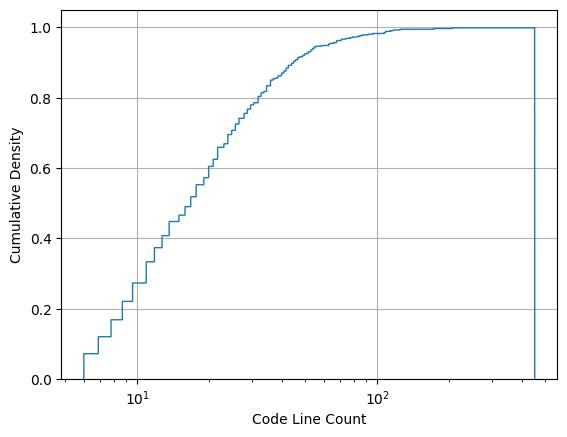

In [7]:
df_remove.complexity_info.map(lambda x: x["code_line_count"]).hist(
    cumulative=True, bins=1000, density=True, histtype="step"
)
plt.xscale("log")
plt.xlabel("Code Line Count")
plt.ylabel("Cumulative Density")